In [2]:
# Setup and Data Initialization
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import gc
import os

print("[*] Loading datasets and spatial infrastructure...")

# 1. File paths
month_file = "includes/flux_gipuzkoa_complet_02-2025.csv"
distritos_path = "includes/gipuzkoa_distritos.shp"
roads_path = "road_gipuzkoa/road_gipuzkoa.shp"
points_path = "points_region_prets.csv"

# 2. Optimized mobility data import (memory management)
df_month = pd.read_csv(
    month_file, 
    usecols=['origen', 'destino', 'viajes', 'fecha'],
    dtype={'origen': 'category', 'destino': 'category', 'viajes': 'float32'}
)

# 3. Geo-data import
gdf_distritos = gpd.read_file(distritos_path)
gdf_gipuzkoa = gdf_distritos[gdf_distritos['ID'].astype(str).str.startswith('20')].copy()
gdf_roads = gpd.read_file(roads_path)
df_p = pd.read_csv(points_path)

# 4. Point calibration (GAMA coordinate alignment)
REF_MIN_X = gdf_distritos.total_bounds[0]
REF_MAX_Y = gdf_distritos.total_bounds[3]
df_p['utm_x'] = df_p['gama_x'] + REF_MIN_X
df_p['utm_y'] = REF_MAX_Y - df_p['gama_y']

gdf_points = gpd.GeoDataFrame(
    df_p, 
    geometry=gpd.points_from_xy(df_p.utm_x, df_p.utm_y), 
    crs="EPSG:25830"
)

# 5. Spatial context plotting function
def roads_and_points(ax, show_roads=True, show_points=True):
    """Overlays road network and POIs for high-visibility mapping."""
    
    # Road network (Black)
    if show_roads:
        gdf_roads.plot(ax=ax, color='black', linewidth=0.45, alpha=0.5, zorder=10)
        
    # POI distribution (Red)
    if show_points:
        gdf_points.plot(ax=ax, color='red', markersize=1.0, alpha=0.2, zorder=11)

print("[+] Setup complete. Assets loaded in memory.")

[*] Loading datasets and spatial infrastructure...
[+] Setup complete. Assets loaded in memory.


Rendering infrastructure layers...


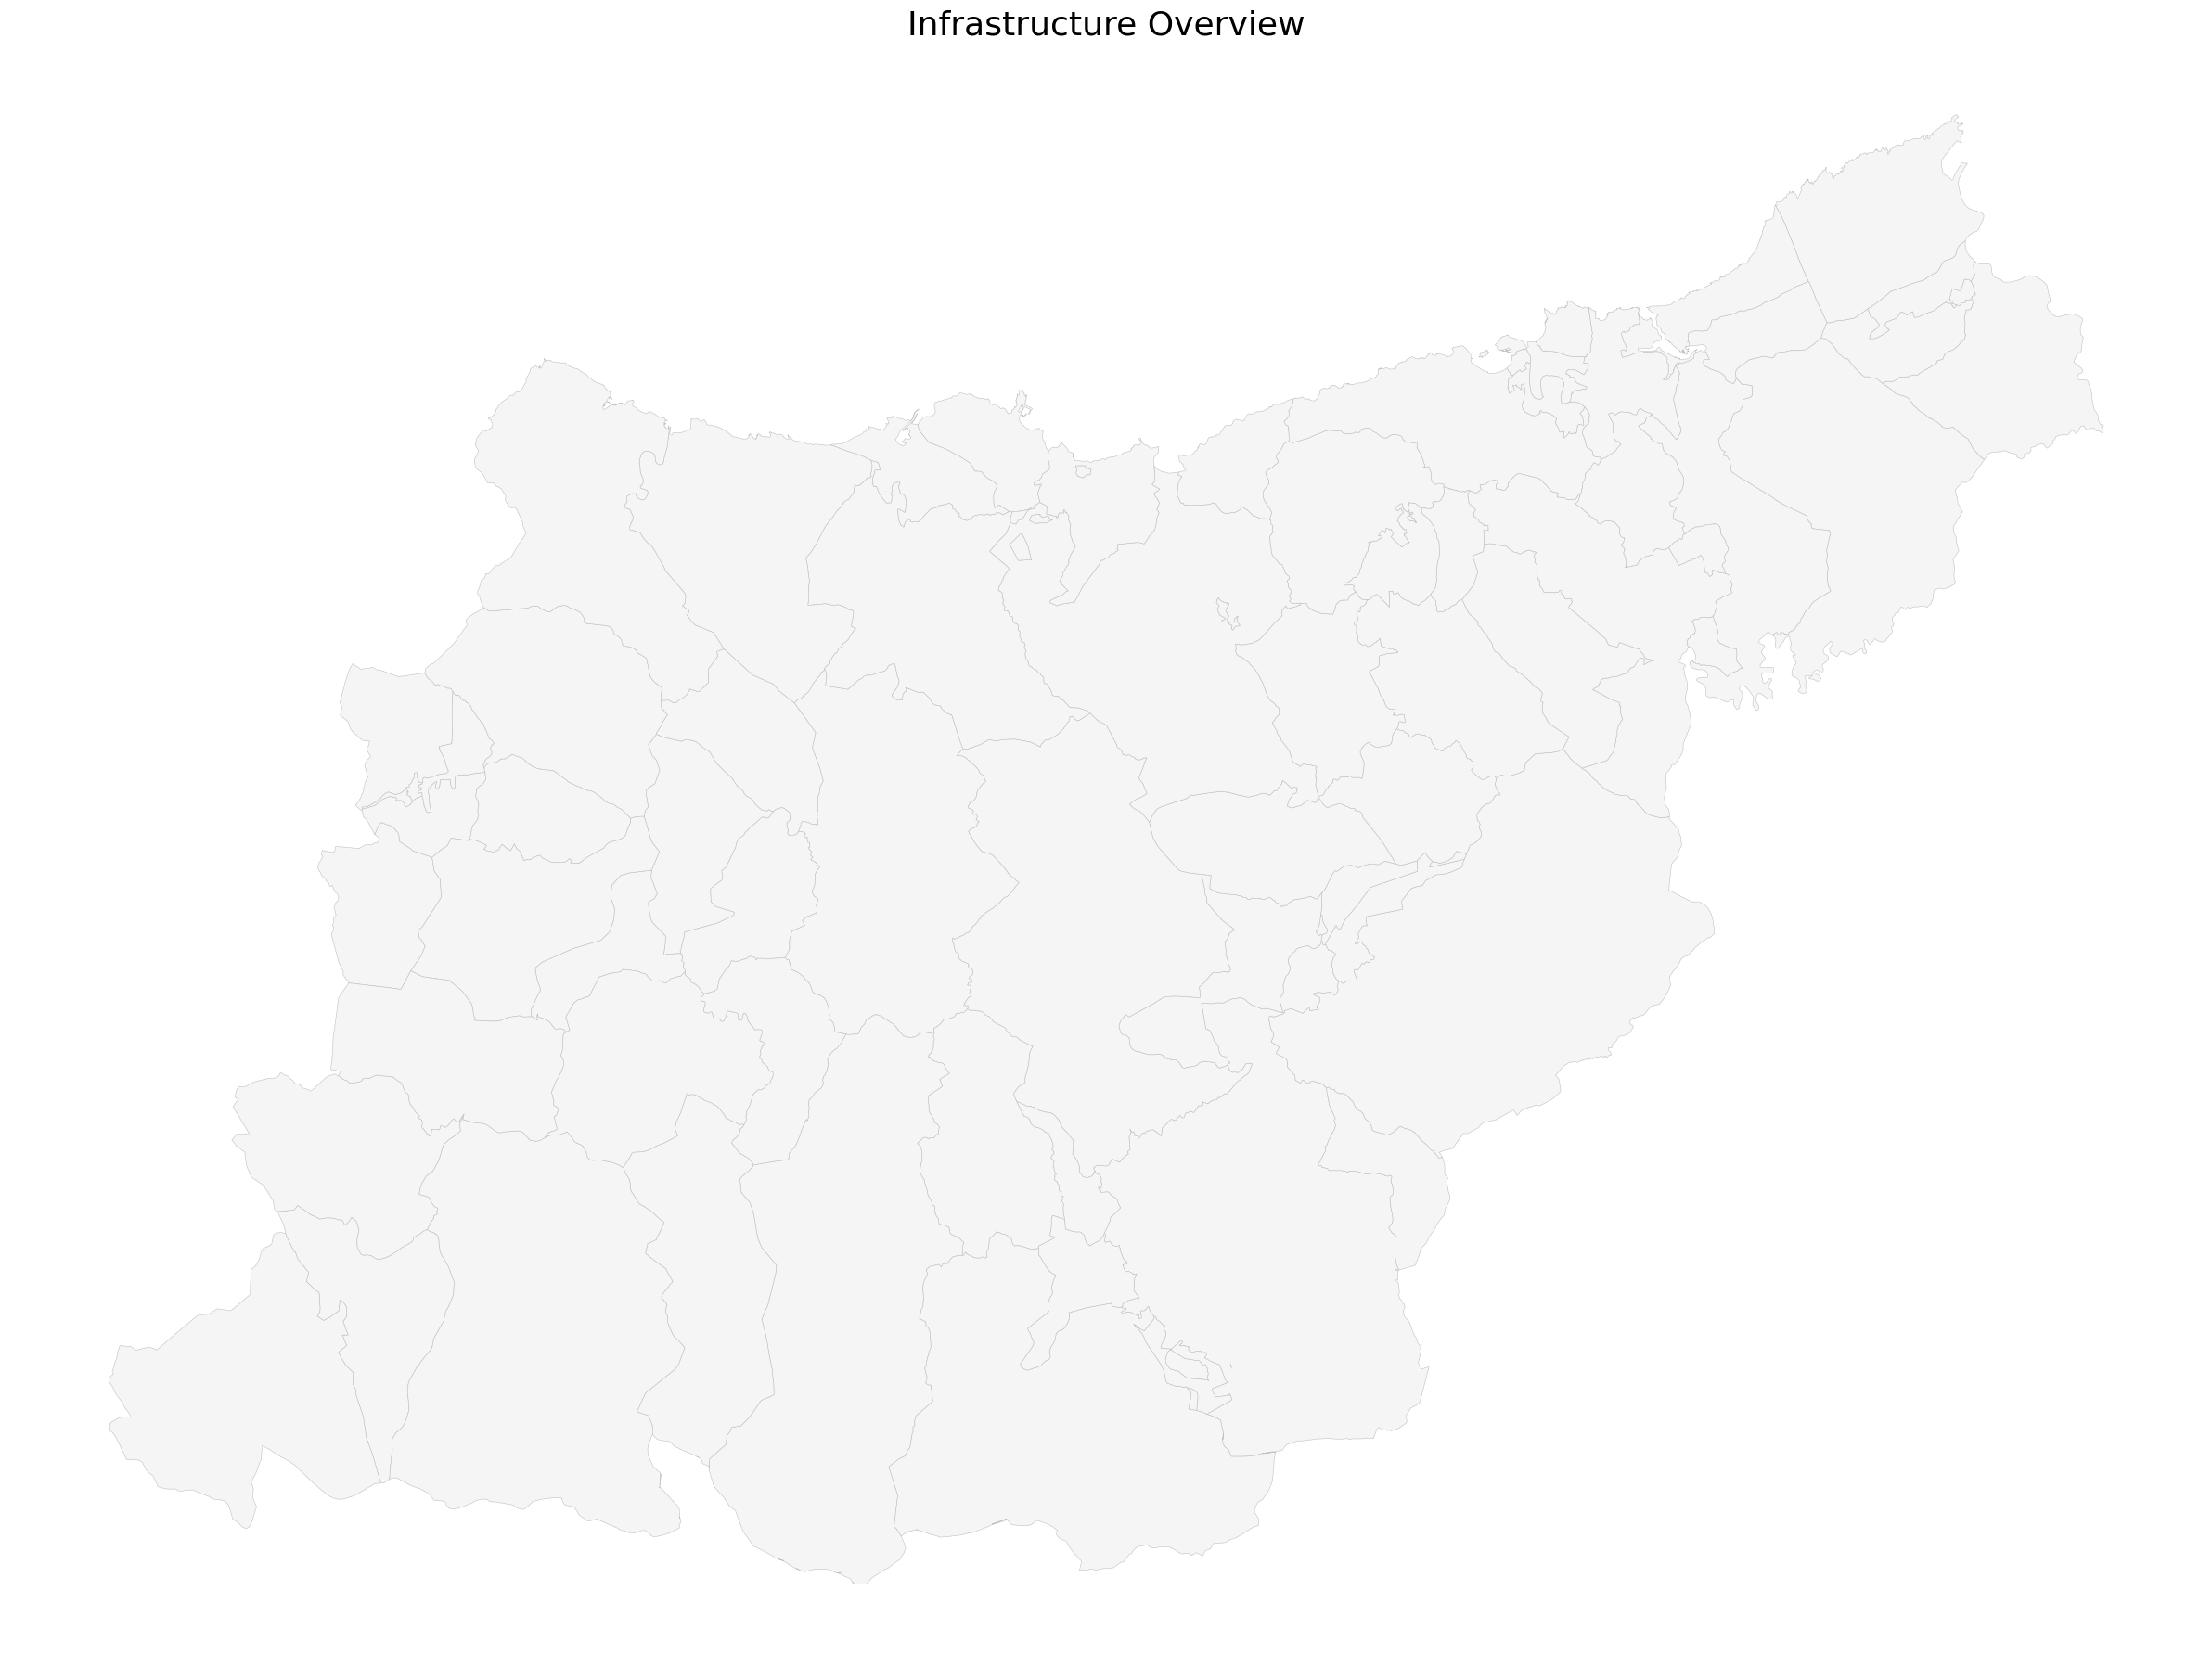

In [3]:
# Infrastructure mapping
print("Rendering infrastructure layers...")

fig, ax = plt.subplots(figsize=(24, 18))

# Background: District boundaries
gdf_gipuzkoa.plot(ax=ax, color='whitesmoke', edgecolor='silver', linewidth=0.4)


ax.set_title("Infrastructure Overview", fontsize=26)
plt.axis('off')

plt.tight_layout()
plt.show()

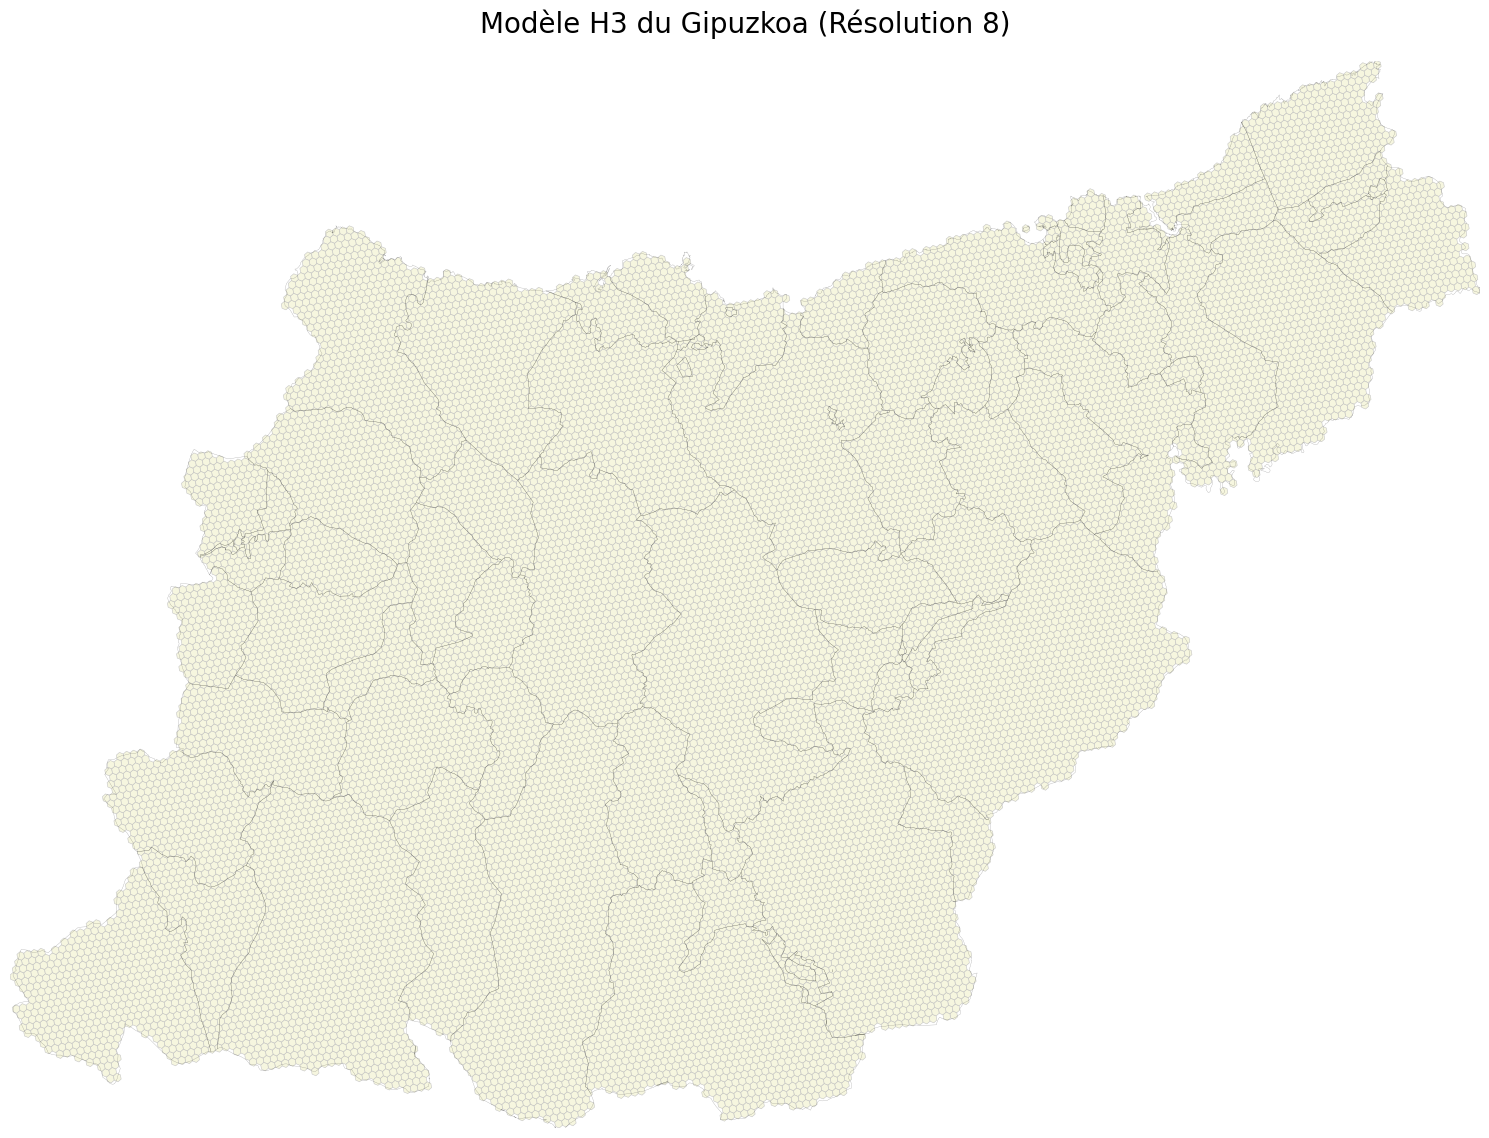

In [4]:
import h3pandas
import matplotlib.pyplot as plt

# 1. Préparation des données (basé sur ton gdf_gipuzkoa)
gdf_h3 = gdf_gipuzkoa.to_crs("EPSG:4326")

# 2. Transformation en modèle H3
# 'explode=True' crée une ligne par hexagone
hex_gdf = gdf_h3.h3.polyfill(9, explode=True)

# --- LA CORRECTION EST ICI ---
# On supprime les districts qui n'ont pas pu être remplis d'hexagones (NaN)
# Cela arrive si une zone est plus petite qu'un hexagone de résolution 8
hex_gdf = hex_gdf.dropna(subset=['h3_polyfill'])

# 3. Maintenant on peut préparer les géométries sans erreur
hex_gdf = hex_gdf.set_index('h3_polyfill').h3.h3_to_geo_boundary()

# 4. Affichage du résultat (ton style graphique)
fig, ax = plt.subplots(figsize=(15, 12))

hex_gdf.plot(
    ax=ax,
    color='#F5F5DC',      # Beige clair
    edgecolor='silver',   # Bordures
    linewidth=0.4,
    alpha=0.9
)

# On ajoute tes limites de districts par-dessus pour vérification
gdf_gipuzkoa.to_crs("EPSG:4326").boundary.plot(ax=ax, color='black', linewidth=0.2, alpha=0.4)

ax.set_title("Modèle H3 du Gipuzkoa (Résolution 8)", fontsize=20, pad=20)
ax.set_axis_off()

# Recadrage automatique sur tes données
minx, miny, maxx, maxy = hex_gdf.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

plt.tight_layout()
plt.show()

[*] Préparation de la grille H3...
[*] Analyse spatiale en cours...
✅ Succès : 55513 points répartis dans la grille.


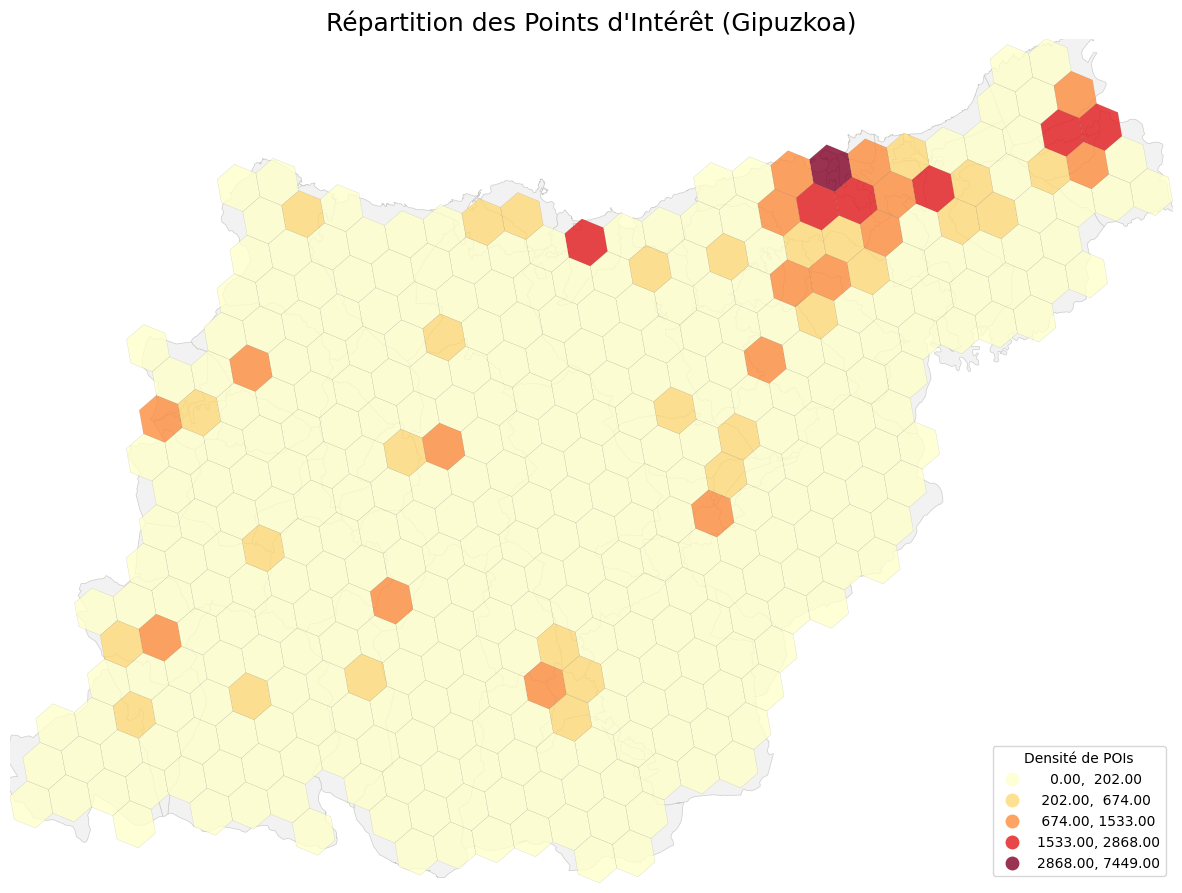

In [9]:
# --- CELLULE HEATMAP AUTO-CORRECTRICE ---

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import h3pandas

# 1. On recrée une grille propre (pour être sûr des noms de colonnes)
print("[*] Préparation de la grille H3...")
gdf_h3_base = gdf_gipuzkoa.to_crs("EPSG:4326")
hex_gdf = gdf_h3_base.h3.polyfill(7, explode=True).dropna(subset=['h3_polyfill'])
hex_gdf = hex_gdf.set_index('h3_polyfill').h3.h3_to_geo_boundary()

# IMPORTANTE : On réinitialise l'index pour simplifier la jointure spatiale
hex_gdf_clean = hex_gdf.reset_index()

# 2. Chargement des points fixes
df_fixes = pd.read_csv("points_fixes.csv")
gdf_p = gpd.GeoDataFrame(
    df_fixes, 
    geometry=gpd.points_from_xy(df_fixes.lng, df_fixes.lat), 
    crs="EPSG:4326"
)

# 3. Jointure Spatiale sécurisée
print("[*] Analyse spatiale en cours...")
points_in_hex = gpd.sjoin(gdf_p, hex_gdf_clean, how="inner", predicate="within")

# Initialisation de la colonne poi_count à 0
hex_gdf_clean['poi_count'] = 0

if points_in_hex.empty:
    print("⚠️ ATTENTION : Aucun point n'a été trouvé à l'intérieur des hexagones !")
    print("Vérifiez que les coordonnées des points et du Gipuzkoa sont dans la même zone.")
else:
    # On compte les points. sjoin crée toujours 'index_right' quand on reset_index()
    counts = points_in_hex.groupby('index_right').size()
    
    # On injecte les comptes dans la grille
    hex_gdf_clean.loc[counts.index, 'poi_count'] = counts.values
    print(f"✅ Succès : {int(hex_gdf_clean['poi_count'].sum())} points répartis dans la grille.")

# 4. AFFICHAGE (Style Heatmap Jaune -> Rouge)
fig, ax = plt.subplots(figsize=(15, 12))

# Fond de carte
gdf_gipuzkoa.to_crs("EPSG:4326").plot(ax=ax, color='#F2F2F2', edgecolor='#CCCCCC', linewidth=0.5)

# Heatmap
# On n'affiche que les hexagones qui ont au moins 1 point pour que ce soit plus joli
# Ou on affiche tout si vous préférez voir la grille complète
hex_gdf_clean.plot(
    column='poi_count',
    cmap='YlOrRd',           # Jaune -> Orange -> Rouge
    scheme='NaturalBreaks',  # Nécessite pip install mapclassify
    k=5, 
    legend=True,
    ax=ax,
    edgecolor='black',
    linewidth=0.05,
    alpha=0.8,
    legend_kwds={'title': "Densité de POIs", 'loc': 'lower right'}
)

ax.set_title("Répartition des Points d'Intérêt (Gipuzkoa)", fontsize=18)
ax.set_axis_off()

# Zoom final
minx, miny, maxx, maxy = hex_gdf_clean.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

plt.show()